<a href="https://colab.research.google.com/github/luladc/IA_DiazLaura/blob/main/practica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Clustering completado para k=3
Clustering completado para k=5
Clustering completado para k=7
Clustering completado para k=9


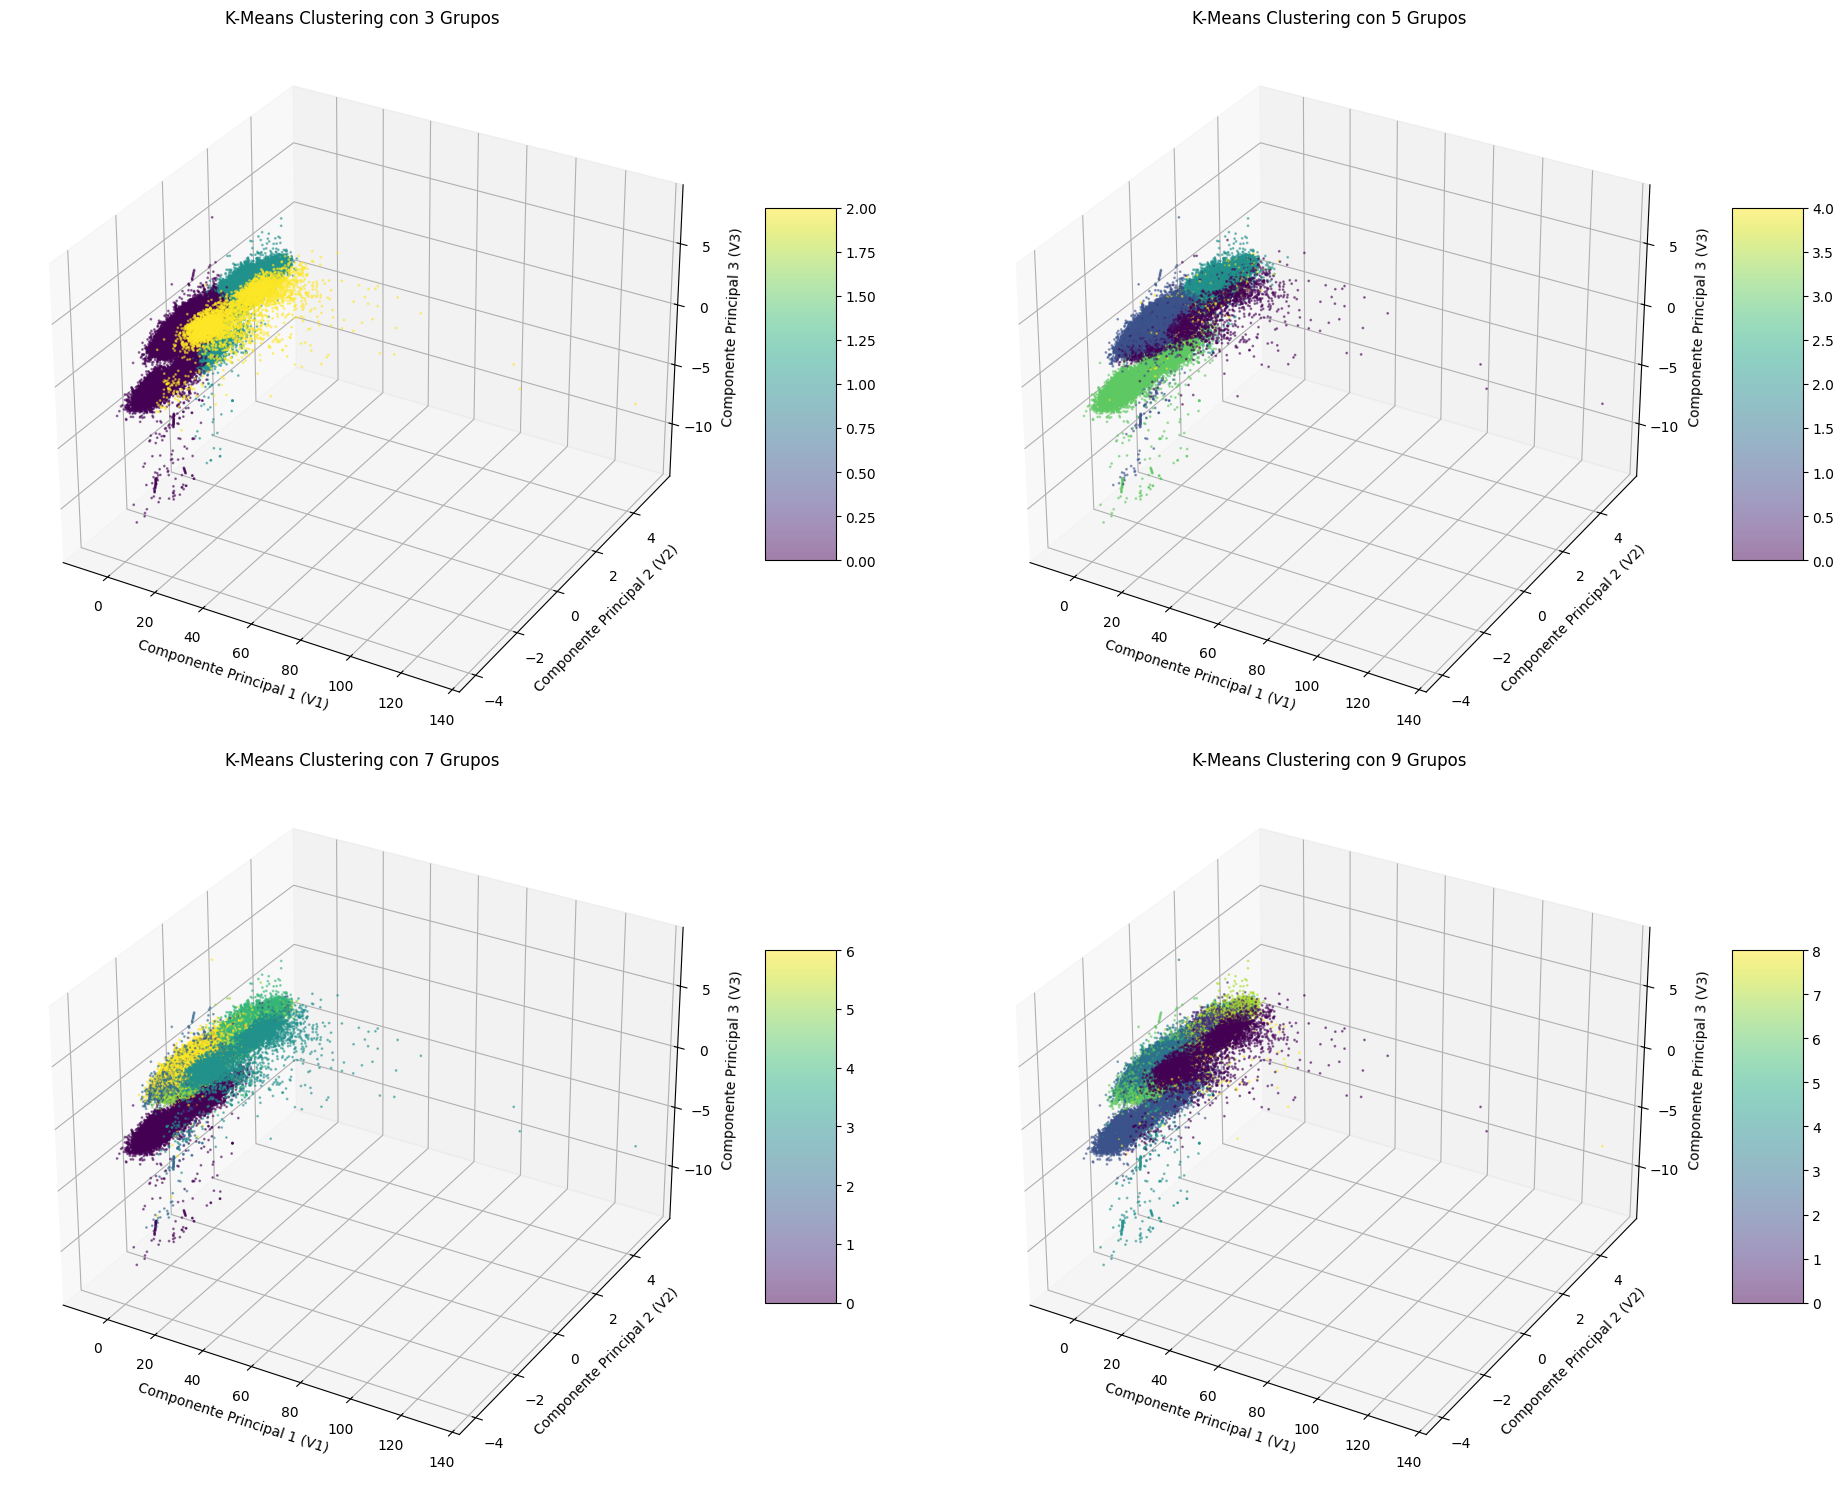

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# 1. Importar el dataset desde Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Cargar el dataset
path = "/content/drive/MyDrive/DATASETS/creditcard.csv"
df = pd.read_csv(path)

# 2. Preprocesamiento
# El dataset es altamente imbalanceado
# Omitimos la columna 'Class' ya que es aprendizaje no supervisado
X = df.drop(['Class'], axis=1)

# Normalización: Crucial para KMeans basado en distancias euclidianas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Aplicar KMeans para diferentes grupos (3, 5, 7, 9)
clusters_list = [3, 5, 7, 9]
models = {}

for k in clusters_list:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    models[k] = kmeans.fit_predict(X_scaled)
    print(f"Clustering completado para k={k}")

# 4. Reducción de dimensionalidad para Visualización 3D (PCA)
# Usamos las 3 características que expliquen la mayor varianza (V1, V2, V3 )
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# 5. Graficar en 3D
fig = plt.figure(figsize=(20, 15))

for i, k in enumerate(clusters_list):
    ax = fig.add_subplot(2, 2, i+1, projection='3d')
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
                         c=models[k], cmap='viridis', s=1, alpha=0.5)
    ax.set_title(f'K-Means Clustering con {k} Grupos')
    ax.set_xlabel('Componente Principal 1 (V1)')
    ax.set_ylabel('Componente Principal 2 (V2)')
    ax.set_zlabel('Componente Principal 3 (V3)')
    fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=5)

plt.tight_layout()
plt.show()